# LDV–PZT contrastive cross-modal alignment

This notebook learns a shared latent space for paired paths:

- LDV input: `X_ldv_virtual`
- PZT input: `X_pzt_baseline`
- Pairing: `pair_idx`
- Output: 8-dimensional normalized embeddings
- Loss: symmetric InfoNCE contrastive loss

This is a **cross-modal feasibility demonstration**, not damage transfer.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PROJECT_DIR=Path.cwd()
if str(PROJECT_DIR) not in sys.path: sys.path.insert(0,str(PROJECT_DIR))
from dl_settings import *
from dl_utils import *

set_seed(RANDOM_SEED)
device=choose_device(DEVICE)
PZT_DIR=DATASET_ROOT/PZT_FOLDER
RESULTS_ROOT=ensure_dir(PROJECT_DIR/RESULTS_FOLDER)
FIG_DIR=ensure_dir(PROJECT_DIR/"figures")
OUT=ensure_dir(RESULTS_ROOT/"11_cross_modal_alignment")
feature_path=find_feature_file(PZT_DIR,FEATURE_FILE_CANDIDATES)
print("Feature file:",feature_path)
print("Device:",device)
print("Results folder:",OUT)
print("Figures folder:",FIG_DIR)

Feature file: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/260609_pzt_network/physics_features_phase1_bpf.npz
Device: cuda
Results folder: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsGPT_Codes/July2_DL_Meeting_work/paper5_dl_results/11_cross_modal_alignment
Figures folder: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsGPT_Codes/July2_DL_Meeting_work/figures


In [2]:
with np.load(feature_path,allow_pickle=False) as z:
    print("Keys:",z.files)
    pair_idx=normalize_pair_idx(z["pair_idx"])
    if "X_ldv_virtual" not in z.files:
        raise KeyError("Selected feature file has no X_ldv_virtual")
    Xl_raw=z["X_ldv_virtual"]
    Xp_raw=z["X_pzt_baseline"]

n_paths=len(pair_idx)
Xl=flatten_samples(to_sample_first(Xl_raw,n_paths))
Xp=flatten_samples(to_sample_first(Xp_raw,n_paths))
groups=reciprocal_group_ids(pair_idx)

ldv_feature_names=[f"ldv_feature_{i:02d}" for i in range(Xl.shape[1])]
pzt_feature_names=[f"pzt_feature_{i:02d}" for i in range(Xp.shape[1])]

print("LDV:",Xl.shape,"PZT:",Xp.shape,"groups:",len(np.unique(groups)))
input_summary=pd.DataFrame([
    {"encoder_input":"LDV encoder","source":"X_ldv_virtual","raw_shape":Xl_raw.shape,"network_shape":Xl.shape,"nan_count":int(np.isnan(Xl).sum()),"inf_count":int(np.isinf(Xl).sum())},
    {"encoder_input":"PZT encoder","source":"X_pzt_baseline","raw_shape":Xp_raw.shape,"network_shape":Xp.shape,"nan_count":int(np.isnan(Xp).sum()),"inf_count":int(np.isinf(Xp).sum())},
])
display(input_summary)
ldv_preview=pd.DataFrame(Xl[:8],columns=ldv_feature_names)
ldv_preview.insert(0,"rx",pair_idx[:8,1])
ldv_preview.insert(0,"src",pair_idx[:8,0])
pzt_preview=pd.DataFrame(Xp[:8],columns=pzt_feature_names)
pzt_preview.insert(0,"rx",pair_idx[:8,1])
pzt_preview.insert(0,"src",pair_idx[:8,0])
print("Raw LDV encoder input before fold-local imputation and scaling:")
display(ldv_preview)
print("Raw PZT encoder input before fold-local imputation and scaling:")
display(pzt_preview)

Keys: ['X_pzt_baseline', 'X_pzt_damage', 'X_ldv_virtual', 'X_ldv_2d', 'X_ldv_extra2d', 'X_ldv_full', 'pair_idx', 'freqs_kHz']
LDV: (30, 10) PZT: (30, 10) groups: 15


,encoder_input,source,raw_shape,network_shape,nan_count,inf_count
0,LDV encoder,X_ldv_virtual,"(30, 10)","(30, 10)",92,0
1,PZT encoder,X_pzt_baseline,"(30, 10)","(30, 10)",90,0


Raw LDV encoder input before fold-local imputation and scaling:


,src,rx,ldv_feature_00,ldv_feature_01,ldv_feature_02,ldv_feature_03,ldv_feature_04,ldv_feature_05,ldv_feature_06,ldv_feature_07,ldv_feature_08,ldv_feature_09
0,1,2,0.0,0.000000,494.562897,141.033859,-0.006654,93.756065,10.0,NaN,NaN,NaN
1,1,3,0.0,129.600006,293.529297,91.007629,0.024280,88.893143,20.0,NaN,NaN,NaN
2,1,4,0.0,67.699997,382.160889,178.619217,-0.001183,83.518639,0.0,NaN,NaN,NaN
3,1,5,0.0,204.699997,474.923187,112.700890,NaN,102.785378,30.0,NaN,NaN,NaN
4,1,6,0.0,0.000000,420.032837,149.368011,0.005484,102.191002,10.0,NaN,NaN,NaN
5,2,1,0.0,75.199997,418.831848,198.057663,0.004291,83.394852,0.0,NaN,NaN,NaN
6,2,3,1.6,180.800003,434.825317,84.584160,0.098615,95.939522,30.0,NaN,NaN,NaN
7,2,4,0.0,0.000000,577.779175,125.007065,-0.004804,92.008080,0.0,NaN,NaN,NaN


Raw PZT encoder input before fold-local imputation and scaling:


,src,rx,pzt_feature_00,pzt_feature_01,pzt_feature_02,pzt_feature_03,pzt_feature_04,pzt_feature_05,pzt_feature_06,pzt_feature_07,pzt_feature_08,pzt_feature_09
0,1,2,70.454544,86.818184,656.746094,276.067902,0.016675,115.437073,0.0,NaN,NaN,NaN
1,1,3,89.545456,423.181824,438.706573,165.548004,0.017190,113.848869,10.0,NaN,NaN,NaN
2,1,4,101.363640,372.272736,787.595398,246.333786,0.016692,98.897171,30.0,NaN,NaN,NaN
3,1,5,87.727272,102.727272,462.491150,186.579010,0.000172,102.310104,40.0,NaN,NaN,NaN
4,1,6,70.000000,86.363640,545.706116,208.825195,0.006977,108.717819,20.0,NaN,NaN,NaN
5,2,1,70.454544,90.000000,601.652039,252.637558,0.017619,115.239349,0.0,NaN,NaN,NaN
6,2,3,71.363640,115.000000,751.157227,304.930756,0.000790,104.010864,10.0,NaN,NaN,NaN
7,2,4,87.727272,246.818176,426.162201,171.090256,0.000401,107.651199,20.0,NaN,NaN,NaN


In [3]:
class Encoder(nn.Module):
    def __init__(self,input_dim,embed_dim=8):
        super().__init__()
        hidden=min(128,max(32,input_dim//2))
        self.net=nn.Sequential(
            nn.Linear(input_dim,hidden),
            nn.ReLU(),
            nn.Dropout(.15),
            nn.Linear(hidden,embed_dim)
        )
    def forward(self,x):
        return F.normalize(self.net(x),dim=-1)

def contrastive_loss(zl,zp,temp=.15):
    logits=zl@zp.T/temp
    labels=torch.arange(len(zl),device=zl.device)
    return .5*(F.cross_entropy(logits,labels)+F.cross_entropy(logits.T,labels))

def fit_impute_scale(X_train,X_test):
    X_train=np.asarray(X_train,dtype=np.float32)
    X_test=np.asarray(X_test,dtype=np.float32)
    fill=np.zeros(X_train.shape[1],dtype=np.float32)
    valid=np.isfinite(X_train)
    for j in range(X_train.shape[1]):
        vals=X_train[valid[:,j],j]
        if len(vals):
            fill[j]=np.median(vals)
    X_train=np.where(np.isfinite(X_train),X_train,fill)
    X_test=np.where(np.isfinite(X_test),X_test,fill)
    scaler=StandardScaler().fit(X_train)
    return scaler.transform(X_train),scaler.transform(X_test)

In [4]:
n_splits=min(5,len(np.unique(groups)))
gkf=GroupKFold(n_splits=n_splits)

latent_ldv=np.full((n_paths,8),np.nan,dtype=np.float32)
latent_pzt=np.full((n_paths,8),np.nan,dtype=np.float32)
rows=[]; detail=[]

for fold,(train_idx,test_idx) in enumerate(gkf.split(Xl,np.zeros(n_paths),groups),1):
    Xltr,Xlte=fit_impute_scale(Xl[train_idx],Xl[test_idx])
    Xptr,Xpte=fit_impute_scale(Xp[train_idx],Xp[test_idx])
    if fold==1:
        display(pd.DataFrame([
            {"actual_network_input":"LDV train tensor","shape":Xltr.shape,"nan_count":int(np.isnan(Xltr).sum()),"inf_count":int(np.isinf(Xltr).sum())},
            {"actual_network_input":"LDV test tensor","shape":Xlte.shape,"nan_count":int(np.isnan(Xlte).sum()),"inf_count":int(np.isinf(Xlte).sum())},
            {"actual_network_input":"PZT train tensor","shape":Xptr.shape,"nan_count":int(np.isnan(Xptr).sum()),"inf_count":int(np.isinf(Xptr).sum())},
            {"actual_network_input":"PZT test tensor","shape":Xpte.shape,"nan_count":int(np.isnan(Xpte).sum()),"inf_count":int(np.isinf(Xpte).sum())},
        ]))
        ldv_network_preview=pd.DataFrame(Xltr[:5],columns=ldv_feature_names)
        ldv_network_preview.insert(0,"row_index",train_idx[:5])
        pzt_network_preview=pd.DataFrame(Xptr[:5],columns=pzt_feature_names)
        pzt_network_preview.insert(0,"row_index",train_idx[:5])
        print("First fold LDV encoder input after imputation and StandardScaler:")
        display(ldv_network_preview)
        print("First fold PZT encoder input after imputation and StandardScaler:")
        display(pzt_network_preview)

    xltr=torch.tensor(Xltr,dtype=torch.float32,device=device)
    xptr=torch.tensor(Xptr,dtype=torch.float32,device=device)
    xlte=torch.tensor(Xlte,dtype=torch.float32,device=device)
    xpte=torch.tensor(Xpte,dtype=torch.float32,device=device)

    el=Encoder(xltr.shape[1],8).to(device)
    ep=Encoder(xptr.shape[1],8).to(device)
    opt=torch.optim.AdamW(list(el.parameters())+list(ep.parameters()),lr=1e-3,weight_decay=1e-4)

    best=(
        {k:v.detach().cpu().clone() for k,v in el.state_dict().items()},
        {k:v.detach().cpu().clone() for k,v in ep.state_dict().items()}
    )
    best_loss=np.inf; wait=0
    for epoch in range(500):
        el.train(); ep.train()
        opt.zero_grad()
        loss=contrastive_loss(el(xltr),ep(xptr))
        loss.backward(); opt.step()
        loss_value=loss.item()
        if not np.isfinite(loss_value):
            wait+=1
            if wait>=50: break
            continue
        if loss_value<best_loss-1e-5:
            best_loss=loss_value
            best=(
                {k:v.detach().cpu().clone() for k,v in el.state_dict().items()},
                {k:v.detach().cpu().clone() for k,v in ep.state_dict().items()}
            )
            wait=0
        else:
            wait+=1
        if wait>=50: break

    el.load_state_dict(best[0]); ep.load_state_dict(best[1])
    el.eval(); ep.eval()
    with torch.no_grad():
        zl=el(xlte).cpu().numpy()
        zp=ep(xpte).cpu().numpy()

    latent_ldv[test_idx]=zl
    latent_pzt[test_idx]=zp

    sim=zl@zp.T
    top1=np.argmax(sim,axis=1)
    correct=np.arange(len(test_idx))
    k=min(3,len(test_idx))
    topk=np.argsort(-sim,axis=1)[:,:k]

    rows.append({
        "fold":fold,
        "n_test":len(test_idx),
        "top1_retrieval_accuracy":np.mean(top1==correct),
        "top3_retrieval_accuracy":np.mean([correct[i] in topk[i] for i in range(len(correct))]),
        "mean_matched_cosine":np.mean(np.diag(sim)),
        "mean_unmatched_cosine":np.mean(sim[~np.eye(len(sim),dtype=bool)]) if len(sim)>1 else np.nan
    })

    for i,idx in enumerate(test_idx):
        ridx=test_idx[top1[i]]
        detail.append({
            "fold":fold,
            "src":pair_idx[idx,0],
            "rx":pair_idx[idx,1],
            "matched_cosine":sim[i,i],
            "retrieved_src":pair_idx[ridx,0],
            "retrieved_rx":pair_idx[ridx,1],
            "correct_top1":int(top1[i]==i)
        })

metrics=pd.DataFrame(rows)
details=pd.DataFrame(detail)
display(metrics)
display(metrics.mean(numeric_only=True))
metrics.to_csv(OUT/"cross_modal_fold_metrics.csv",index=False)
details.to_csv(OUT/"cross_modal_retrieval_details.csv",index=False)

,actual_network_input,shape,nan_count,inf_count
0,LDV train tensor,"(24, 10)",0,0
1,LDV test tensor,"(6, 10)",0,0
2,PZT train tensor,"(24, 10)",0,0
3,PZT test tensor,"(6, 10)",0,0


First fold LDV encoder input after imputation and StandardScaler:


,row_index,ldv_feature_00,ldv_feature_01,ldv_feature_02,ldv_feature_03,ldv_feature_04,ldv_feature_05,ldv_feature_06,ldv_feature_07,ldv_feature_08,ldv_feature_09
0,0,-0.387285,-1.217723,0.273395,-0.266313,-0.687466,0.011830,-0.267261,0.0,0.0,0.0
1,1,-0.387285,0.713054,-1.186120,-1.096031,0.393887,-0.535617,0.534523,0.0,0.0,0.0
2,2,-0.387285,-0.209130,-0.542650,0.357066,-0.496219,-1.140655,-1.069045,0.0,0.0,0.0
3,3,-0.387285,1.831892,0.130810,-0.736234,-0.304873,1.028312,1.336306,0.0,0.0,0.0
4,5,-0.387285,-0.097396,-0.276416,0.679465,-0.304873,-1.154591,-1.069045,0.0,0.0,0.0


First fold PZT encoder input after imputation and StandardScaler:


,row_index,pzt_feature_00,pzt_feature_01,pzt_feature_02,pzt_feature_03,pzt_feature_04,pzt_feature_05,pzt_feature_06,pzt_feature_07,pzt_feature_08,pzt_feature_09
0,0,-1.556365,-0.815342,-0.127757,-0.027394,0.606163,1.465792,-1.192079,0.0,0.0,0.0
1,1,0.148869,2.062907,-1.167627,-1.177657,0.654473,1.137257,-0.397360,0.0,0.0,0.0
2,2,1.204491,1.627280,0.496287,-0.336859,0.607698,-1.955652,1.192079,0.0,0.0,0.0
3,3,-0.013534,-0.679208,-1.054194,-0.958772,-0.941790,-1.249653,1.986799,0.0,0.0,0.0
4,5,-1.556365,-0.788115,-0.390510,-0.271251,0.694634,1.424891,-1.192079,0.0,0.0,0.0


,fold,n_test,top1_retrieval_accuracy,top3_retrieval_accuracy,mean_matched_cosine,mean_unmatched_cosine
0,1,6,0.333333,0.500000,-0.085177,-0.110465
1,2,6,0.000000,0.500000,-0.149730,-0.157461
2,3,6,0.166667,0.333333,-0.160280,-0.011137
3,4,6,0.000000,0.166667,-0.283147,0.083053
4,5,6,0.000000,0.333333,-0.252992,-0.060875


fold                       3.000000
n_test                     6.000000
top1_retrieval_accuracy    0.100000
top3_retrieval_accuracy    0.366667
mean_matched_cosine       -0.186265
mean_unmatched_cosine     -0.051377
dtype: float64

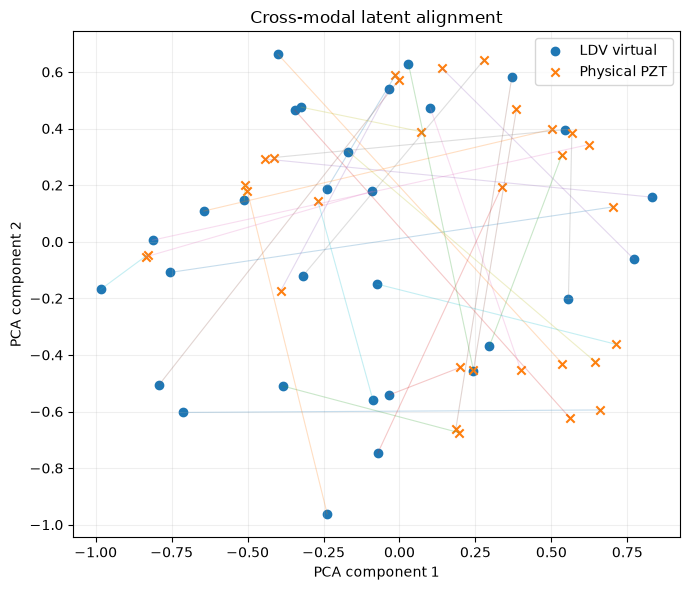

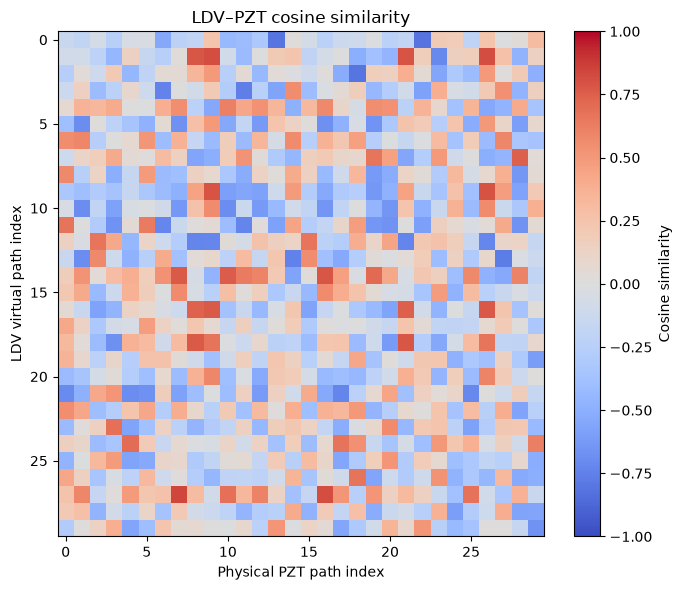

In [5]:
combined=np.vstack([latent_ldv,latent_pzt])
xy=PCA(n_components=2,random_state=RANDOM_SEED).fit_transform(combined)
xy_ldv=xy[:n_paths]; xy_pzt=xy[n_paths:]

fig,ax=plt.subplots(figsize=(7,6))
for i in range(n_paths):
    ax.plot([xy_ldv[i,0],xy_pzt[i,0]],[xy_ldv[i,1],xy_pzt[i,1]],alpha=.25,lw=.8)
ax.scatter(xy_ldv[:,0],xy_ldv[:,1],label="LDV virtual",marker="o")
ax.scatter(xy_pzt[:,0],xy_pzt[:,1],label="Physical PZT",marker="x")
ax.set_title("Cross-modal latent alignment")
ax.set_xlabel("PCA component 1"); ax.set_ylabel("PCA component 2")
ax.legend(); ax.grid(alpha=.2)
fig.tight_layout()
fig.savefig(FIG_DIR/"11_Figure_cross_modal_latent_alignment.png",dpi=300,bbox_inches="tight")
plt.show()

sim_global=latent_ldv@latent_pzt.T
fig,ax=plt.subplots(figsize=(7,6))
im=ax.imshow(sim_global,cmap="coolwarm",vmin=-1,vmax=1,aspect="auto")
ax.set_xlabel("Physical PZT path index"); ax.set_ylabel("LDV virtual path index")
ax.set_title("LDV–PZT cosine similarity")
fig.colorbar(im,ax=ax,label="Cosine similarity")
fig.tight_layout()
fig.savefig(FIG_DIR/"11_Figure_cross_modal_similarity_matrix.png",dpi=300,bbox_inches="tight")
plt.show()

np.save(OUT/"latent_ldv_oof.npy",latent_ldv)
np.save(OUT/"latent_pzt_oof.npy",latent_pzt)

## Meeting wording

Use:  
**“A dual-encoder contrastive model aligned corresponding LDV-derived virtual receiver and physical PZT path features.”**

Do not claim paired LDV supervision for the magnet state.